# 01b - Sensitivity analysis: rho, T, and lambda

`01_simulate_pd_panel` fixes three calibration choices that shape how hard the decision
problem is and how much room there is between the foresight oracle and the Bayes oracle:

- `RHO_SCALE` (currently 0.05): scales the Basel asset correlation used for the
  **realised loss draw** (not the regulatory K_IRB formula, which always uses the full,
  unscaled Basel correlation - only the simulated charge-off draws are scaled down);
- `T` (currently 1000): the number of simulated quarters;
- `lambda_shortfall` (currently 10.0): the weight on the shortfall penalty in the
  allocation utility.

This notebook explores what changing each of these would do to the decision environment,
**without retraining PTO / black-box / DFL** (that is expensive and only worth doing once
you have committed to a new calibration - if you decide to change one of these for real,
change it in `01_simulate_pd_panel`'s calibration cell and rerun the full 01 to 04
pipeline). Instead, this notebook works directly with the cheap, closed-form parts of the
pipeline - the realised-loss draw, the foresight oracle, and the analytic Bayes oracle -
reusing the already-simulated latent PD path (`PD_quarterly_true`, `PD_annual_true`,
`K_IRB_true`) from the saved panel so the only things that change across each sweep are
the parameter being tested.

**Read this alongside the discussion of why the foresight/Bayes gap is currently small**:
that gap (`regret_irreducible`) is driven almost entirely by how much the realised draw
can differ from its conditional mean, which is controlled by `rho` (via `RHO_SCALE`) and
amplified or dampened by `lambda_shortfall`. `T` does not change that gap on average; it
only changes how precisely you can *estimate* it (and any other summary statistic) from a
finite sample - which is a fundamentally different kind of sensitivity from the other two.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import minimize_scalar
from scipy.special import owens_t

pd.set_option("display.float_format", "{:.6f}".format)

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "simulation" / "data" / "simulated_pd_panel.csv").exists():
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT))
from minou_colors import MINOU_COLORS

DATA_DIR = ROOT / "simulation" / "data"
FIGURE_DIR = ROOT / "simulation" / "figures" / "01b_sensitivity"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PANEL_CSV = DATA_DIR / "simulated_pd_panel.csv"
METADATA_PATH = DATA_DIR / "simulated_pd_panel_metadata.json"

import json as _json
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    META = _json.load(f)
CONST = META["constants"]

LGD = float(CONST["LGD"])
K1 = float(CONST["K1"])
ell = float(CONST["ell"])
Y_BAR = float(CONST["Y_BAR"])
LAMBDA_BASELINE = float(CONST["lambda_shortfall"])
RHO_SCALE_BASELINE = float(CONST.get("RHO_SCALE", 1.0))
ALPHA_BOUNDS = (0.0, 1.0)
ALPHA_OPT_XATOL = float(CONST.get("alpha_opt_xatol", 1e-10))
PD_CLIP_LOW, PD_CLIP_HIGH = 1e-6, 0.99

panel = pd.read_csv(PANEL_CSV)
T_BASELINE = int(CONST["T_after_lag_drop"])
print(f"Baseline calibration: RHO_SCALE={RHO_SCALE_BASELINE}, T={T_BASELINE}, "
      f"lambda_shortfall={LAMBDA_BASELINE}")
print(f"Panel rows available: {len(panel)}")
display(panel[["t", "PD_quarterly_true", "PD_annual_true", "R_true", "K_IRB_true", "c"]].head())


Baseline calibration: RHO_SCALE=0.05, T=999, lambda_shortfall=10.0
Panel rows available: 999


,t,PD_quarterly_true,PD_annual_true,R_true,K_IRB_true,c
0,0,0.004930,0.019574,0.165096,0.091328,0.002093
1,1,0.006202,0.024577,0.155116,0.097269,0.002501
2,2,0.003253,0.012948,0.182810,0.080652,0.001006
3,3,0.003445,0.013711,0.180459,0.082144,0.001175
4,4,0.003464,0.013783,0.180241,0.082281,0.001270


## Shared machinery

Reused, unchanged, from `01_simulate_pd_panel` / `02_pto_simulated_panel`: the allocation
utility, the continuous-optimum solver (Brent's method, no grid), and the analytic
Vasicek expected-shortfall formula used for the Bayes oracle. `K_IRB_true` is read
directly from the panel rather than recomputed, because it depends only on
`PD_annual_true` and the fixed, unscaled Basel correlation - `RHO_SCALE` never touches it,
only the realised-loss draw does.


In [2]:
def clip_pd(pd_):
    return np.clip(np.asarray(pd_, dtype=float), PD_CLIP_LOW, PD_CLIP_HIGH)


def basel_R(pd_annual):
    pd_annual = clip_pd(pd_annual)
    exp_term = (1 - np.exp(-50 * pd_annual)) / (1 - np.exp(-50))
    return 0.12 * exp_term + 0.24 * (1 - exp_term)


def realised_utility(alpha, c, k, lambda_shortfall, K1=K1, ell=ell, y_bar=Y_BAR):
    exposure = ell * alpha * K1
    terminal_capital = K1 + exposure * (y_bar - c)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = k * exposure
    shortfall = np.maximum(required_capital - available_buffer, 0.0)
    utility = terminal_capital - lambda_shortfall * shortfall
    return {"utility": utility, "shortfall": shortfall}


def realised_alpha_star(c_t, k_t, lambda_shortfall):
    """Continuous-optimum realised allocation for one (c, k) draw (Brent's method,
    no grid) - see 01_simulate_pd_panel for the full derivation and consistency checks."""
    def neg_utility(alpha):
        return -float(realised_utility(alpha, c_t, k_t, lambda_shortfall)["utility"])
    opt = minimize_scalar(neg_utility, bounds=ALPHA_BOUNDS, method="bounded",
                          options={"xatol": ALPHA_OPT_XATOL})
    candidates = [(0.0, -neg_utility(0.0)), (1.0, -neg_utility(1.0)), (float(opt.x), -float(opt.fun))]
    alpha_star, u_star = max(candidates, key=lambda item: item[1])
    return alpha_star, u_star


def bivariate_normal_cdf(h, k, rho):
    h = np.asarray(h, dtype=float); k = np.asarray(k, dtype=float)
    rho = np.clip(np.asarray(rho, dtype=float), -0.999999, 0.999999)
    denom = np.sqrt(np.maximum(1.0 - rho ** 2, 1e-300))
    h_safe = np.where(h == 0.0, 1e-12, h); k_safe = np.where(k == 0.0, 1e-12, k)
    a = (k / h_safe - rho) / denom; b = (h / k_safe - rho) / denom
    val = 0.5 * (norm.cdf(h) + norm.cdf(k)) - owens_t(h_safe, a) - owens_t(k_safe, b)
    hk = h * k
    delta = np.where((hk > 0.0) | ((hk == 0.0) & (h + k >= 0.0)), 0.0, 0.5)
    return val - delta


def vasicek_expected_shortfall(x, pd_q, rho):
    x = np.asarray(x, dtype=float)
    pd_q = float(clip_pd(pd_q)); rho = float(np.clip(rho, 1e-6, 1.0 - 1e-6))
    a = norm.ppf(pd_q); sqrt_rho = np.sqrt(rho); sqrt_1mrho = np.sqrt(1.0 - rho)
    x_clipped = np.clip(x, PD_CLIP_LOW, PD_CLIP_HIGH)
    y_x = (a - norm.ppf(x_clipped) * sqrt_1mrho) / sqrt_rho
    es = bivariate_normal_cdf(a, y_x, sqrt_rho) - x_clipped * norm.cdf(y_x)
    es = np.where(x <= 0.0, pd_q - x, es)
    es = np.where(x >= 1.0, 0.0, es)
    return np.maximum(es, 0.0)


def bayes_alpha_star(pd_q_t, k_t, rho_t, lambda_shortfall):
    """Analytic-closed-form Bayes oracle (see 01_simulate_pd_panel / 02_pto_simulated_panel):
    maximises expected utility over the Vasicek distribution implied by the true PD."""
    def expected_utility(alpha):
        alpha = float(alpha)
        etc = K1 + ell * alpha * (Y_BAR - LGD * pd_q_t)
        if alpha <= 0.0:
            return etc
        x = ((1.0 - alpha) + ell * alpha * (Y_BAR - k_t)) / (ell * alpha * LGD)
        es = vasicek_expected_shortfall(np.array([x]), pd_q_t, rho_t)[0]
        return etc - lambda_shortfall * ell * alpha * LGD * es
    opt = minimize_scalar(lambda a: -expected_utility(a), bounds=ALPHA_BOUNDS, method="bounded",
                          options={"xatol": ALPHA_OPT_XATOL})
    candidates = [(0.0, expected_utility(0.0)), (1.0, expected_utility(1.0)), (float(opt.x), -float(opt.fun))]
    return max(candidates, key=lambda item: item[1])


def resample_c(pd_q_true, pd_a_true, rho_scale, z):
    """Realised charge-off draw for a given systematic shock z and RHO_SCALE - identical
    formula to 01_simulate_pd_panel's sample_vasicek_default_rate, but taking z directly
    so the same shock path can be reused across different RHO_SCALE values."""
    rho = np.clip(rho_scale * basel_R(pd_a_true), 1e-4, 0.999)
    default_rate = norm.cdf((norm.ppf(clip_pd(pd_q_true)) - np.sqrt(rho) * z) / np.sqrt(1 - rho))
    return np.clip(LGD * np.clip(default_rate, 0, 1), 0, LGD)


def evaluate_panel(c, k_true, pd_q_true, pd_a_true, rho_scale, lambda_shortfall):
    """Foresight oracle, Bayes oracle, and their gap, for one full set of per-quarter
    draws/parameters. Returns a per-quarter DataFrame."""
    rows = []
    for c_t, k_t, pdq_t, pda_t in zip(c, k_true, pd_q_true, pd_a_true):
        alpha_o, u_o = realised_alpha_star(c_t, k_t, lambda_shortfall)
        rho_t = float(np.clip(rho_scale * basel_R(pda_t), 1e-4, 0.999))
        alpha_b, _ = bayes_alpha_star(pdq_t, k_t, rho_t, lambda_shortfall)
        u_b_realised = float(realised_utility(alpha_b, c_t, k_t, lambda_shortfall)["utility"])
        shortfall_o = float(realised_utility(alpha_o, c_t, k_t, lambda_shortfall)["shortfall"])
        rows.append({"alpha_oracle": alpha_o, "utility_oracle": u_o, "alpha_bayes": alpha_b,
                    "utility_bayes_realised": u_b_realised,
                    "regret_irreducible": u_o - u_b_realised,
                    "shortfall_oracle": shortfall_o, "c": c_t})
    return pd.DataFrame(rows)


## A. Sensitivity to `RHO_SCALE`

`RHO_SCALE` scales the Basel asset correlation used only for the realised-loss draw:
`rho = RHO_SCALE * basel_R(PD_annual_true)`. As `rho -> 0`, the Vasicek draw
`c = LGD * Phi((Phi^-1(PD) - sqrt(rho)*Z) / sqrt(1-rho))` collapses to the deterministic
point `LGD * PD` regardless of the systematic shock `Z` - the infinite-granularity
assumption has already diversified away idiosyncratic risk, so `rho` is the only lever
left controlling how far realised draws can wander from their conditional mean. At the
current `RHO_SCALE = 0.05` (effective rho roughly 0.006-0.012 given Basel R of
0.12-0.24), that collapse is nearly complete - hence the small foresight/Bayes gap.

**Design of this sweep**: the systematic shock `Z` is drawn once (fixed seed) and reused
identically across every `RHO_SCALE` value, so the comparison isolates the effect of
`rho` alone rather than mixing it with new sampling noise.

**Expectation**: mean irreducible regret, the dispersion of realised `c`, and the
dispersion of the foresight-oracle allocation should all increase monotonically with
`RHO_SCALE`, since a larger rho widens the loss distribution around its mean and gives
the systematic factor more room to produce draws the Bayes oracle could not have
committed to in advance.


In [3]:
RHO_SCALE_GRID = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]

rng_rho = np.random.default_rng(123)
Z_FIXED = rng_rho.normal(0, 1, size=len(panel))

pd_q_true = panel["PD_quarterly_true"].to_numpy()
pd_a_true = panel["PD_annual_true"].to_numpy()
k_true = panel["K_IRB_true"].to_numpy()

rho_rows = []
rho_panels = {}
for rho_scale in RHO_SCALE_GRID:
    c_resampled = resample_c(pd_q_true, pd_a_true, rho_scale, Z_FIXED)
    res = evaluate_panel(c_resampled, k_true, pd_q_true, pd_a_true, rho_scale, LAMBDA_BASELINE)
    rho_panels[rho_scale] = res
    rho_rows.append({
        "rho_scale": rho_scale,
        "mean_c": float(res["c"].mean()), "std_c": float(res["c"].std()),
        "mean_regret_irreducible": float(res["regret_irreducible"].mean()),
        "median_regret_irreducible": float(res["regret_irreducible"].median()),
        "max_regret_irreducible": float(res["regret_irreducible"].max()),
        "std_alpha_oracle": float(res["alpha_oracle"].std()),
        "shortfall_bind_share": float((res["shortfall_oracle"] > 1e-12).mean()),
    })
rho_summary = pd.DataFrame(rho_rows).set_index("rho_scale")
display(rho_summary)
rho_summary.to_csv(DATA_DIR / "sensitivity_rho_scale.csv")


,mean_c,std_c,mean_regret_irreducible,median_regret_irreducible,max_regret_irreducible,std_alpha_oracle,shortfall_bind_share
rho_scale,,,,,,,
0.010000,0.001861,0.001393,0.000338,0.000265,0.010569,0.076824,0.007007
0.020000,0.001857,0.001407,0.000507,0.000393,0.017178,0.076813,0.009009
0.050000,0.001850,0.001457,0.000898,0.000680,0.035345,0.076794,0.010010
0.100000,0.001843,0.001552,0.001439,0.001048,0.066017,0.076780,0.008008
0.200000,0.001836,0.001753,0.002418,0.001687,0.134311,0.076774,0.008008
0.500000,0.001831,0.002385,0.005291,0.003422,0.401542,0.079171,0.008008
1.000000,0.001849,0.003511,0.010920,0.006254,1.094062,0.104698,0.010010


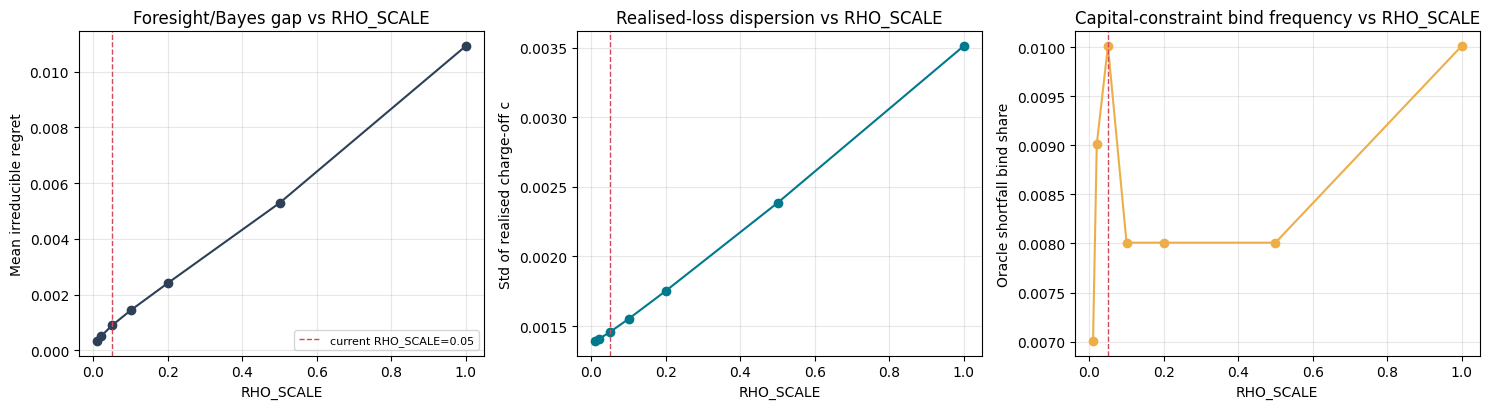

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(rho_summary.index, rho_summary["mean_regret_irreducible"], marker="o", color=MINOU_COLORS["navy"])
axes[0].axvline(RHO_SCALE_BASELINE, color=MINOU_COLORS["coral"], ls="--", lw=1, label=f"current RHO_SCALE={RHO_SCALE_BASELINE}")
axes[0].set_xlabel("RHO_SCALE"); axes[0].set_ylabel("Mean irreducible regret"); axes[0].legend(fontsize=8)
axes[0].set_title("Foresight/Bayes gap vs RHO_SCALE")

axes[1].plot(rho_summary.index, rho_summary["std_c"], marker="o", color=MINOU_COLORS["teal"])
axes[1].axvline(RHO_SCALE_BASELINE, color=MINOU_COLORS["coral"], ls="--", lw=1)
axes[1].set_xlabel("RHO_SCALE"); axes[1].set_ylabel("Std of realised charge-off c")
axes[1].set_title("Realised-loss dispersion vs RHO_SCALE")

axes[2].plot(rho_summary.index, rho_summary["shortfall_bind_share"], marker="o", color=MINOU_COLORS["gold"])
axes[2].axvline(RHO_SCALE_BASELINE, color=MINOU_COLORS["coral"], ls="--", lw=1)
axes[2].set_xlabel("RHO_SCALE"); axes[2].set_ylabel("Oracle shortfall bind share")
axes[2].set_title("Capital-constraint bind frequency vs RHO_SCALE")

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "rho_scale_sensitivity.png", dpi=200, bbox_inches="tight")
plt.show()


## B. Sensitivity to `lambda_shortfall`

`lambda_shortfall` only enters the utility function - it never touches the DGP or the
realised charge-off draws - so this sweep reuses the panel's own realised `c` (baseline
`RHO_SCALE`) and just recomputes both oracles' allocations and utilities under each
`lambda`. No new random draws are needed, so this comparison is exact, not simulation
noise.

**Expectation, and a subtlety worth knowing before you look at the plot**: utility is
piecewise-linear and concave in alpha with a single kink, and that kink's *location*
(`alpha* = K1 / A` for some `A` depending only on `c` and `k`, not on `lambda`) does not
move as `lambda` changes. What `lambda` controls is whether the optimum sits at that kink
at all: below a (quarter-specific) threshold, the shortfall penalty is too mild to deter
going further, so the oracle jumps to full commitment (`alpha=1`); above that threshold,
the oracle locks onto the kink exactly, and - because the kink location does not depend on
`lambda` - it **stays there as `lambda` grows further**, however large. So the expected
shape of oracle allocation vs `lambda` is a threshold-like drop from ~1 down to the
population's average kink value, which then flattens out, not a smoothly declining curve
all the way down. The shortfall-bind share should fall towards zero once most quarters
have crossed their threshold (right at the kink, shortfall is exactly zero by
construction). Mean irreducible regret should still generally *increase* with `lambda`
throughout, because the same-sized realised surprise costs more whenever it pushes the
allocation across the now-more-expensive kink.


In [5]:
LAMBDA_GRID = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]

c_baseline = panel["c"].to_numpy()

lambda_rows = []
lambda_panels = {}
for lam in LAMBDA_GRID:
    res = evaluate_panel(c_baseline, k_true, pd_q_true, pd_a_true, RHO_SCALE_BASELINE, lam)
    lambda_panels[lam] = res
    lambda_rows.append({
        "lambda_shortfall": lam,
        "mean_alpha_oracle": float(res["alpha_oracle"].mean()),
        "mean_alpha_bayes": float(res["alpha_bayes"].mean()),
        "mean_regret_irreducible": float(res["regret_irreducible"].mean()),
        "median_regret_irreducible": float(res["regret_irreducible"].median()),
        "shortfall_bind_share": float((res["shortfall_oracle"] > 1e-12).mean()),
        "mean_utility_oracle": float(res["utility_oracle"].mean()),
    })
lambda_summary = pd.DataFrame(lambda_rows).set_index("lambda_shortfall")
display(lambda_summary)
lambda_summary.to_csv(DATA_DIR / "sensitivity_lambda_shortfall.csv")


,mean_alpha_oracle,mean_alpha_bayes,mean_regret_irreducible,median_regret_irreducible,shortfall_bind_share,mean_utility_oracle
lambda_shortfall,,,,,,
0.100000,0.746075,0.746033,0.000093,0.000012,0.876877,1.095012
0.500000,0.615086,0.613523,0.000388,0.000294,0.186186,1.092963
1.000000,0.615086,0.612664,0.000504,0.000386,0.085085,1.092963
2.000000,0.615086,0.611879,0.000617,0.000468,0.047047,1.092963
5.000000,0.615086,0.610909,0.000778,0.000594,0.022022,1.092963
10.000000,0.615086,0.610208,0.000886,0.000683,0.013013,1.092963
20.000000,0.615086,0.609527,0.001014,0.000777,0.008008,1.092963
50.000000,0.615086,0.608648,0.001156,0.000899,0.000000,1.092963
100.000000,0.615086,0.607996,0.001272,0.000996,0.000000,1.092963


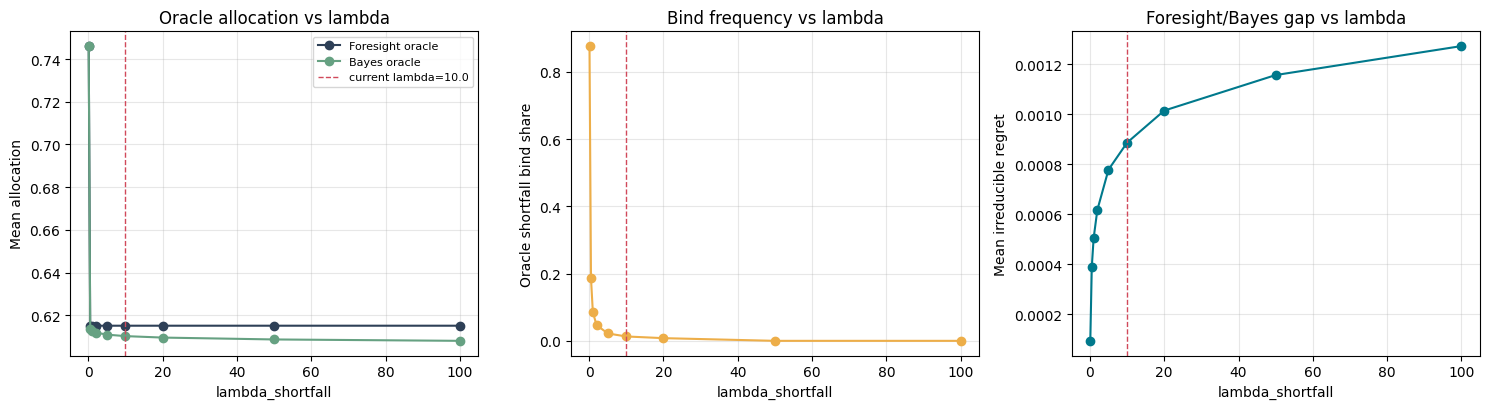

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(lambda_summary.index, lambda_summary["mean_alpha_oracle"], marker="o", color=MINOU_COLORS["navy"], label="Foresight oracle")
axes[0].plot(lambda_summary.index, lambda_summary["mean_alpha_bayes"], marker="o", color=MINOU_COLORS["sage"], label="Bayes oracle")
axes[0].axvline(LAMBDA_BASELINE, color=MINOU_COLORS["coral"], ls="--", lw=1, label=f"current lambda={LAMBDA_BASELINE}")
axes[0].set_xlabel("lambda_shortfall"); axes[0].set_ylabel("Mean allocation"); axes[0].legend(fontsize=8)
axes[0].set_title("Oracle allocation vs lambda")

axes[1].plot(lambda_summary.index, lambda_summary["shortfall_bind_share"], marker="o", color=MINOU_COLORS["gold"])
axes[1].axvline(LAMBDA_BASELINE, color=MINOU_COLORS["coral"], ls="--", lw=1)
axes[1].set_xlabel("lambda_shortfall"); axes[1].set_ylabel("Oracle shortfall bind share")
axes[1].set_title("Bind frequency vs lambda")

axes[2].plot(lambda_summary.index, lambda_summary["mean_regret_irreducible"], marker="o", color=MINOU_COLORS["teal"])
axes[2].axvline(LAMBDA_BASELINE, color=MINOU_COLORS["coral"], ls="--", lw=1)
axes[2].set_xlabel("lambda_shortfall"); axes[2].set_ylabel("Mean irreducible regret")
axes[2].set_title("Foresight/Bayes gap vs lambda")

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lambda_sensitivity.png", dpi=200, bbox_inches="tight")
plt.show()


## C. Sensitivity to `T`

`T` is qualitatively different from the other two: it does not change the decision
problem itself (the per-quarter DGP, the oracle/Bayes gap, the utility function are all
identical regardless of how many quarters you simulate), it only changes how much data
you have to *estimate* things from - both the summary statistics in this notebook and,
downstream, how much training/test data PTO, the black box, and DFL get in the expanding
window. This notebook cannot cheaply demonstrate the downstream training effect (that
needs the actual PyTorch training loops in 02/03/04), but it can demonstrate the
estimation-precision effect directly: how tightly you can pin down a statistic like
`mean_regret_irreducible` shrinks as you use more of the panel.

**Method**: block-bootstrap the panel's existing 1000 quarters at growing sample sizes
`T'` and compute the standard error of the sample mean of `regret_irreducible` (baseline
`RHO_SCALE` and `lambda_shortfall`) at each `T'`. This is honest about what it is and
is not: it shows how estimate precision scales with the amount of data used from the
*existing* simulated history, not what would happen with a genuinely longer/different
1000+ quarter macro path (that would require rerunning the latent macro simulation in
`01_simulate_pd_panel` with a larger `T` and is out of scope here).

**Expectation**: standard error should shrink roughly like `1/sqrt(T)` (the standard
Monte Carlo rate), flattening out - i.e. diminishing returns to simulating more quarters
purely for the purpose of pinning down these particular summary statistics. The separate,
real reason to want a larger `T` is downstream: more expanding-window test quarters means
more statistical power for the eventual Diebold-Mariano comparisons between PTO / black
box / DFL, and a longer training history at each refit, which is a training-data-quantity
question this notebook cannot answer cheaply.


In [7]:
T_GRID = [50, 100, 200, 400, 600, 800, 1000]
N_BOOTSTRAP = 500

baseline_res = evaluate_panel(c_baseline, k_true, pd_q_true, pd_a_true, RHO_SCALE_BASELINE, LAMBDA_BASELINE)
regret_full = baseline_res["regret_irreducible"].to_numpy()

rng_boot = np.random.default_rng(7)
t_rows = []
for T_prime in T_GRID:
    T_prime = min(T_prime, len(regret_full))
    boot_means = np.empty(N_BOOTSTRAP)
    for b in range(N_BOOTSTRAP):
        idx = rng_boot.integers(0, len(regret_full), size=T_prime)
        boot_means[b] = regret_full[idx].mean()
    t_rows.append({"T_prime": T_prime, "bootstrap_se": float(boot_means.std()),
                  "point_estimate": float(regret_full[:T_prime].mean())})
t_summary = pd.DataFrame(t_rows).set_index("T_prime")
display(t_summary)
t_summary.to_csv(DATA_DIR / "sensitivity_T.csv")


,bootstrap_se,point_estimate
T_prime,,
50,0.000484,0.000857
100,0.000325,0.000787
200,0.000217,0.000852
400,0.000157,0.000864
600,0.000126,0.000842
800,0.000105,0.000930
999,0.000095,0.000886


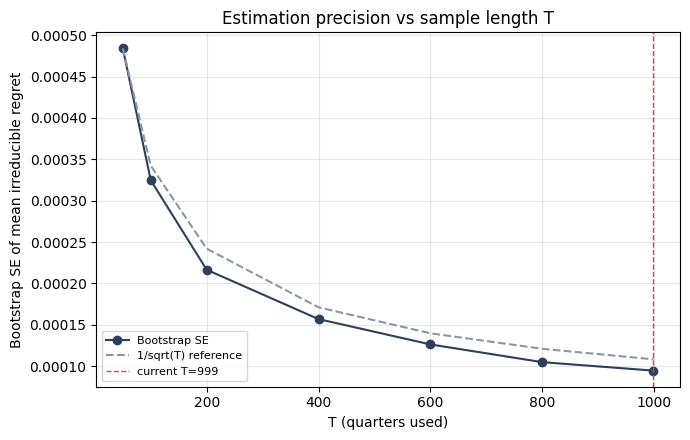

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(t_summary.index, t_summary["bootstrap_se"], marker="o", color=MINOU_COLORS["navy"], label="Bootstrap SE")
ref = t_summary["bootstrap_se"].iloc[0] * np.sqrt(t_summary.index[0] / t_summary.index)
ax.plot(t_summary.index, ref, ls="--", color=MINOU_COLORS["grey"], label="1/sqrt(T) reference")
ax.axvline(T_BASELINE, color=MINOU_COLORS["coral"], ls="--", lw=1, label=f"current T={T_BASELINE}")
ax.set_xlabel("T (quarters used)"); ax.set_ylabel("Bootstrap SE of mean irreducible regret")
ax.set_title("Estimation precision vs sample length T")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "T_sensitivity.png", dpi=200, bbox_inches="tight")
plt.show()


## D. How much of the decision problem is "interesting"?

Following on from the lambda discussion: at `lambda_shortfall = 0` the shortfall term is
multiplied away entirely, utility becomes purely linear in alpha, and the optimal
decision collapses to a corner solution - `alpha = 1` whenever `y_bar > c`, `alpha = 0`
otherwise. That decision only needs the **sign** of `y_bar - c` to be right, not its
magnitude, so essentially any reasonably-behaved model (PTO, the black box, DFL,
persistence) lands on the same allocation regardless of how well it predicts - not
because the methods become equivalent, but because the decision problem stops being
sensitive to prediction quality at all. This is exactly why PTO and DFL would look
identical at `lambda = 0`: DFL's entire value proposition is training the predictor on
the decision loss where prediction errors cost something asymmetric and nontrivial (the
kink), and there is no kink left to exploit.

This section makes that concrete by classifying, for each `lambda`, every quarter's
**oracle** allocation as either a **corner** solution (`alpha` at exactly 0 or 1 - the
decision only needed the sign right, "trivial") or an **interior** solution (`alpha`
strictly between 0 and 1, sitting at the kink - the decision needed the precise
magnitude, "interesting", and only these are quarters where a smarter model can actually
distinguish itself). The corner share should be high near `lambda = 0` and fall toward
zero as `lambda` grows past each quarter's threshold; the interior share does the
opposite. Wherever the interior share is small, PTO/BB/DFL comparisons have little room
to differ - the reverse of the small-`rho` argument from section A, but acting on the
same underlying gap for a different reason.


In [9]:
LAMBDA_GRID_WIDE = [1e-6, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]
CORNER_TOL = 1e-6

trivial_share_lambda0 = float((Y_BAR > c_baseline).mean())
print(f"Share of quarters with y_bar > c (the lambda=0 'always invest fully' condition): "
      f"{trivial_share_lambda0:.3f}")

corner_rows = []
for lam in LAMBDA_GRID_WIDE:
    alphas = np.array([realised_alpha_star(c_t, k_t, lam)[0] for c_t, k_t in zip(c_baseline, k_true)])
    at_corner = (alphas <= CORNER_TOL) | (alphas >= 1.0 - CORNER_TOL)
    corner_rows.append({"lambda_shortfall": lam,
                        "corner_share": float(at_corner.mean()),
                        "interior_share": float((~at_corner).mean()),
                        "mean_alpha": float(alphas.mean())})
corner_summary = pd.DataFrame(corner_rows).set_index("lambda_shortfall")
display(corner_summary)
corner_summary.to_csv(DATA_DIR / "sensitivity_lambda_corner_share.csv")


Share of quarters with y_bar > c (the lambda=0 'always invest fully' condition): 1.000


,corner_share,interior_share,mean_alpha
lambda_shortfall,,,
0.000001,1.000000,0.000000,1.000000
0.001000,1.000000,0.000000,1.000000
0.010000,1.000000,0.000000,1.000000
0.050000,0.990991,0.009009,0.995310
0.100000,0.425425,0.574575,0.746075
0.200000,0.000000,1.000000,0.615086
0.500000,0.000000,1.000000,0.615086
1.000000,0.000000,1.000000,0.615086
2.000000,0.000000,1.000000,0.615086


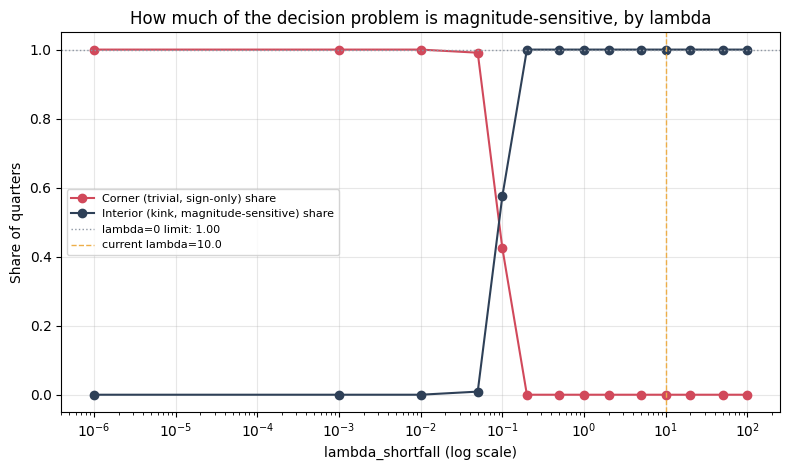

At the current calibration (lambda=10.0), interior share ~= 1.000 of quarters (nearest grid point lambda=10.0) - this is the share of the panel where PTO/BB/DFL differences can actually show up.


In [10]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(corner_summary.index, corner_summary["corner_share"], marker="o", color=MINOU_COLORS["coral"],
       label="Corner (trivial, sign-only) share")
ax.plot(corner_summary.index, corner_summary["interior_share"], marker="o", color=MINOU_COLORS["navy"],
       label="Interior (kink, magnitude-sensitive) share")
ax.axhline(trivial_share_lambda0, color=MINOU_COLORS["grey"], ls=":", lw=1,
          label=f"lambda=0 limit: {trivial_share_lambda0:.2f}")
ax.axvline(LAMBDA_BASELINE, color=MINOU_COLORS["gold"], ls="--", lw=1, label=f"current lambda={LAMBDA_BASELINE}")
ax.set_xscale("log")
ax.set_xlabel("lambda_shortfall (log scale)"); ax.set_ylabel("Share of quarters")
ax.set_title("How much of the decision problem is magnitude-sensitive, by lambda")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lambda_corner_vs_interior_share.png", dpi=200, bbox_inches="tight")
plt.show()

nearest_lambda = min(corner_summary.index, key=lambda x: abs(x - LAMBDA_BASELINE))
interior_at_baseline = float(corner_summary.loc[nearest_lambda, "interior_share"])
print(f"At the current calibration (lambda={LAMBDA_BASELINE}), interior share ~= "
      f"{interior_at_baseline:.3f} of quarters (nearest grid point lambda={nearest_lambda}) - "
      f"this is the share of the panel where PTO/BB/DFL differences can actually show up.")


## Summary

- **`RHO_SCALE`**: the main lever on how large the foresight/Bayes gap (irreducible
  regret) is, and on how often the capital constraint binds. Increasing it materially
  widens the gap between what a perfectly-specified model (Bayes oracle) can achieve and
  what perfect hindsight achieves - useful if you want PTO/BB/DFL to have more headroom
  to be *meaningfully* wrong, since at the current 0.05 the irreducible noise floor is
  small and most of the achievable regret is likely concentrated in estimation error
  rather than genuine bad luck.
- **`lambda_shortfall`**: reshapes the whole allocation problem's risk aversion. Larger
  values push both oracles toward lower, more conservative allocations, reduce how often
  the constraint binds (the oracle avoids it more), but *increase* mean irreducible
  regret, since a given-sized surprise costs more when it crosses the kink. Changing this
  changes what "good" looks like for every model, not just how hard the problem is.
- **`T`**: does not change the decision problem or the size of the foresight/Bayes gap on
  average - it only changes how precisely you can measure it, at roughly a `1/sqrt(T)`
  rate. The real cost of a small `T` shows up downstream, in how much data PTO/BB/DFL get
  to train on and how much statistical power the eventual DM tests have - which this
  notebook does not test directly (would require rerunning the full pipeline with a
  longer simulated panel).
- **Corner vs interior decisions (section D)**: `lambda` does not just rescale regret, it
  determines what fraction of the panel is even capable of separating PTO from DFL from
  the black box. Near `lambda = 0` almost every quarter is a sign-only corner decision
  and no model's prediction quality matters; the interior (kink-bound, magnitude
  sensitive) share grows with `lambda` and is the only part of the panel where
  decision-focused training over predict-then-optimise has anything to exploit. Worth
  checking this share at whatever `lambda` you finally commit to, since a very low
  interior share would make any PTO-vs-DFL comparison uninformative regardless of how
  well each model is implemented.

If you decide to commit to new values for any of these, the actual change happens in
`01_simulate_pd_panel`'s calibration cell; this notebook is exploratory only and does not
modify the saved panel or metadata.
